<a href="https://colab.research.google.com/github/astrockragh/GNN_tutorials/blob/main/CRAQ_galaxy_environment_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### By: [Christian Kragh Jespersen](https://astrockragh.github.io/) [<img src ="https://cdn-icons-png.flaticon.com/512/25/25231.png" alt="drawing" width="20" style="background-color: transparent"/>](https://github.com/astrockragh) [<img src="https://raw.githubusercontent.com/tlmakinen/FieldIMNNs/master/tutorial/plots/twitter-graphic.png" alt="drawing" width="20" style="background-color: transparent"/>](https://twitter.com/astrockragh?lang=en ""), Princeton University (e-mail: ckragh@princeton.edu)

Remember to first change the Runtime to a GPU runtime for a nice speedup

In [ ]:
# we're going to be using Pytorch, the most widely used framework for ML research right now.
# Pytorch is already installed so all we have to worry about is that everything else we do is compatible with our version of Pytorch
import torch
import os
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

2.3.0+cu121


In [ ]:
#here we load the libraries needed for doing ML on graphs, pytorch geometric, and a little package (accelerate) that can help with making our training faster
!pip install torch-geometric \
  torch-sparse \
  torch-scatter \
  torch-cluster \
  -f https://pytorch-geometric.com/whl/torch-${TORCH}.html
!pip install accelerate

Looking in links: https://pytorch-geometric.com/whl/torch-2.3.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 37.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 25.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 8.3 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using

## Now everything is installed, so let's import it all!

In [ ]:
import pickle, time, os
import numpy as np
import os.path as osp
import matplotlib.pyplot as plt
import random
import string
from tqdm import tqdm
from accelerate import Accelerator
from datetime import date

import torch_geometric as tg
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

from IPython import display
import matplotlib as mpl

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 16}

mpl.rc('font', **font)

#### Now let's download some data. All data features have had a Gaussian quantile transformation applied, so all of their distributions are as close as possible to Gaussian. This just aids in the stability of the training. The full train/test set that we want to use is available in [this folder](https://drive.google.com/drive/u/0/folders/1Ng3mBNPdwaztc_fr46ZNZgSSO819vmSv)

#### Everything is downloaded to a non - permanent folder and is within the RAM limits of this notebook, so don't worry about your Drive 😉

#### If this does not work (Google puts a limit on the total number of gdown calls in a 24 hr period), just go the links below and add the files to your personal drive manually and import them from there, then everything should be okay!

In [ ]:
!gdown --folder "https://drive.google.com/drive/folders/1lc11rgIn1l2ncpPHVXS_81G8944wLFbR?usp=drive_link" # 0.3 Mpc
!gdown --folder "https://drive.google.com/drive/folders/18MsknvnLkmVguYKHAZ0pI7Oimw6ImA2h?usp=drive_link" # 1.0 Mpc
!gdown --folder 'https://drive.google.com/drive/folders/1ZW-II-gl7UPTKsgAsfGvYLOyHL6ksm9V?usp=drive_link' # 1.8 Mpc
!gdown --folder "https://drive.google.com/drive/folders/1echtFL7o3FKgq3GYjjH5-jK10ZgcbZcf?usp=drive_link" # 3.0 Mpc

Retrieving folder contents
Retrieving folder 1Mz2vfrvqy7TTRp3eoJD2zftmaMaIaz69 envs
Processing file 1gZVvn_ErCNHZ0d9Kr-ec_E2geAzSva2B data.pkl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1gZVvn_ErCNHZ0d9Kr-ec_E2geAzSva2B
To: /content/tree_env_all_z0.0quantile_dlink0.3_0/envs/data.pkl
100% 29.0M/29.0M [00:00<00:00, 217MB/s]
Download completed
Retrieving folder contents
Retrieving folder 1A0jHM67SDq10ZPPwaXXJJdFBhGJnzcL7 envs
Processing file 1ffHDxm8Yhc-ehiJHuEaL7Gw35TGyCnFR data.pkl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1ffHDxm8Yhc-ehiJHuEaL7Gw35TGyCnFR
From (redirected): https://drive.google.com/uc?id=1ffHDxm8Yhc-ehiJHuEaL7Gw35TGyCnFR&confirm=t&uuid=1c302627-028c-46e6-aaa7-b44507d210e7
To: /content/tree_env_all_z0.0quantile_dlink3.0_0/envs/data.pk

In [ ]:
# train_data, test_data = pickle.load(open('tree_env_all_z0.0quantile_dlink0.3_0/envs/data.pkl', 'rb'))
train_data, test_data = pickle.load(open('tree_env_all_z0.0quantile_dlink1.0_0/envs/data.pkl', 'rb'))
# train_data, test_data = pickle.load(open('tree_env_all_z0.0quantile_dlink1.8_0/envs/data.pkl', 'rb'))
# train_data, test_data = pickle.load(open('tree_env_all_z0.0quantile_dlink3.0_0/envs/data.pkl', 'rb'))


### Let's take a look at the data we have. The files that have been downloaded are with galaxies assumed to be directly connected on respectively 0.3, 1 and 3 Mpc length scales. Start with plotting the 1 Mpc scale, 3 Mpc takes a **long time** to draw (the number of edges scale as $L^3$).

In [ ]:
def visualize_graph(data, draw_edges=True, projection="3d", edge_index=None, boxsize=1, fontsize=12, fig_path=None, name = None):

    fig = plt.figure(figsize=(8, 8), dpi=100)
    print(f'Plotting {int(len(data.x))} halos')
    if projection=="3d":
        ax = fig.add_subplot(projection="3d")
        pos = boxsize/2*data.pos[:,:3]
        mass = data.x[:,0]+abs(min(data.x[:,0]))
    elif projection=="2d":
        ax = fig.add_subplot()
        pos = boxsize/2*data.pos[:,:2]
        mass = data.x[:,0]+abs(min(data.x[:,0]))

    # Draw lines for each edge
    print(f'Drawing {int(len(data.edge_index[0]))} edges')
    if data.edge_index is not None and draw_edges:
        for (src, dst) in tqdm(data.edge_index.t().tolist()):

            src = pos[src].tolist()
            dst = pos[dst].tolist()
            if projection=="3d":
                ax.plot([src[0], dst[0]], [src[1], dst[1]], zs=[src[2], dst[2]], linewidth=20/data.edge_attr.shape[0]**(1/3), color='black')
            elif projection=="2d":
                ax.plot([src[0], dst[0]], [src[1], dst[1]], linewidth=20/data.edge_attr.shape[0]**(1/3), color='black')

    # Plot nodes
    if projection=="3d":
        sc = ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=4**(mass/4), zorder=1000, vmin=3, vmax=8.3, alpha=0.4, edgecolor='k', c=mass, cmap="plasma", linewidths=0.1)
    elif projection=="2d":
        sc = ax.scatter(pos[:, 0], pos[:, 1], s=4**(mass/5), zorder=1000, alpha=0.5, edgecolor='k', c=mass, vmin=3, vmax=8.3,  cmap="plasma", linewidths=0.1)
    plt.subplots_adjust(right=0.8)

    if projection == "3d":
        cb = fig.colorbar(sc, shrink=0.8, aspect=50, location='top', pad=-0.03)
    else:
        cb = fig.colorbar(sc, shrink=0.805, aspect=40, location="top", pad=0.03)
    cb.set_label("Transformed Mass", fontsize=fontsize)

    ax.xaxis.set_tick_params(labelsize=fontsize)
    ax.yaxis.set_tick_params(labelsize=fontsize)
    ax.set_xlabel("X [Mpc]", fontsize=fontsize)
    ax.set_ylabel("Y [Mpc]", fontsize=fontsize)

    if projection=="3d":
        ax.zaxis.set_tick_params(labelsize=fontsize)
        ax.set_zlabel("Z [Mpc]", fontsize=fontsize)
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.xaxis._axinfo["grid"]['color'] =  (0.5,0.5,0.5,0.2)
        ax.yaxis._axinfo["grid"]['color'] =  (0.5,0.5,0.5,0.2)
        ax.zaxis._axinfo["grid"]['color'] =  (0.5,0.5,0.5,0.2)
    else:
        ax.set_aspect("equal")
        ax.grid(alpha=0.15)

    fig.tight_layout()
    if fig_path:
        if projection == "3d":
            fig.savefig(f"{fig_path}/cosmic_web_{name}.png", dpi = 100)
        else:
            fig.savefig(f"{fig_path}/cosmic_web_{name}_projection.png", dpi = 100)

    # plt.close()

Plotting 11267 halos
Drawing 56926 edges


100%|██████████| 56926/56926 [01:46<00:00, 536.81it/s]


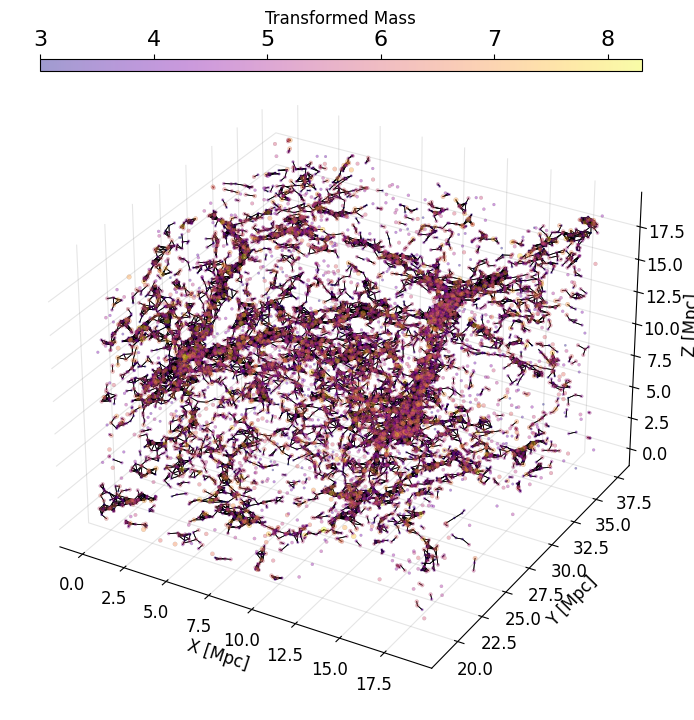

In [ ]:
# always plot the test data, the training data is much too large!
visualize_graph(test_data, draw_edges = True, fig_path = None, name = None)

### The structure of each file is simple, there are two `PyTorch Geometric` `Data` objects, the first corresponding to our training graph, and the second to our test graph. The test graph is quite simply made as a cut-out of a section of the simulation.

### Each halo has a highly multi-dimensional (30) feature space, containing information about the halo profile, mass, spin and so on. For reference the features (ignore the numbers in parentheses) are:

```
['Mvir(10)', 'Rvir(11)', 'rs(12)', 'vrms(13)', 'vmax(16)',
'x(17)','y(18)', 'z(19)', 'vx(20)', 'vy(21)', 'vz(22)',
 'Spin(26)','Tidal_Force(35)', 'Rs_Klypin', 'Mvir_all',
 'M200b', 'M200c', 'M500c', 'M2500c', 'Xoff', 'Voff', 'Spin_Bullock',
 'b_to_a','c_to_a', 'A[x]', 'A[y]', 'A[z]', 'b_to_a(500c)', 'c_to_a(500c)',
 'A[x](500c)', 'A[y](500c)', 'A[z](500c)', 'T/|U|',
  'M_pe_Behroozi', 'M_pe_Diemer', 'Halfmass_Radius']
```

### These are all informative, but probably too complex to be easily interpretable, so let's restrict ourself to halo masses, $M_{\mathrm{Halo}}$. Below we'll select only the first column of x, as well of the position and velocity columns.

### Each halo furthermore contains a galaxy with a similary multi-dimensional (20) feature space. All of these are interesting to predict, but let's restrict ourselves to predicting the stellar mass $M_{\mathrm{*}}$. The relation between the mass of a halo and the mass of a galaxy residing in that halo is fundamental to both galaxy evolution and cosmology.

### Some of the other targets are cold gas mass (index 8), and SFR (13). These targets are not transformed, but this is usually fine for the targets!

In [ ]:
# feats = [0, 5, 6, 7, 8, 9, 10] #
# feats = np.arange(30)
feats = [0]

targ = [0]
test_data.x = test_data.x[:,feats].view(-1, len(feats))
test_data.y = test_data.y[:,targ].view(-1, len(targ))

train_data.x = train_data.x[:,feats].view(-1, len(feats))
train_data.y = train_data.y[:,targ].view(-1, len(targ))



## Before we get started with the GNN, we need to make a **baseline** which does not use any graph structure. Any kind of simple algorithm will serve, linear/non-parametric models or such. Here we'll just pick a normal MLP to do the job. This is **always** a crucial step, one that most astronomers/physicists forget.

In [ ]:
import torch.nn.functional as F
from torch.nn import Linear, LayerNorm, LeakyReLU, Module, ReLU, Sequential, ModuleList
from torch import cat, square,zeros, clone, abs, sigmoid, float32, tanh, clamp

class MLP(Module):
    def __init__(self, n_in, n_out, hidden=64, nlayers=2, layer_norm=True):
        super().__init__()
        '''Simple MLP class with ReLU activiation + layernorm'''
        layers = [Linear(n_in, hidden), ReLU()]
        for i in range(nlayers):
            layers.append(Linear(hidden, hidden))
            layers.append(ReLU())
        if layer_norm:
            layers.append(LayerNorm(hidden))
        layers.append(Linear(hidden, n_out))
        self.mlp = Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

In [ ]:
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP(len(train_data.x[0]), len(train_data.y[0]), hidden = 16, nlayers = 3)

train_data_single = [[train_data.x[i], train_data.y[i]] for i in range(len(train_data.x))]
test_data_single = [[test_data.x[i], test_data.y[i]] for i in range(len(test_data.x))]

train_loader = DataLoader(train_data_single, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data_single, batch_size=256, shuffle=False)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

accelerator = Accelerator()
_, _, test_loader = accelerator.prepare(model, optimizer, test_loader)
model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)


In [ ]:
# prompt: make a training loop for the above code
def train_loop(model, train_loader, test_loader, optimizer, n_epochs):
    for epoch in tqdm(range(n_epochs)):
        model.train()
        for data in train_loader:
            optimizer.zero_grad()
            out = model(data[0])
            loss = F.mse_loss(out, data[1])
            accelerator.backward(loss)
            optimizer.step()
            optimizer.zero_grad()

        if int(epoch) % (n_epochs/20) == 0:
          model.eval()
          with torch.no_grad():
              test_mse = torch.zeros(1)
              for data in test_loader:
                  out = model(data[0])
                  test_mse += F.mse_loss(out, data[1]).item()
              test_mse /= len(test_loader)
              print(f'Epoch: {epoch+1:02d}, Test scatter: {torch.sqrt(test_mse)[0]:.4f}')

train_loop(model, train_loader, test_loader, optimizer, n_epochs=20)


  5%|▌         | 1/20 [00:01<00:37,  1.95s/it]

Epoch: 01, Test scatter: 0.2784


 10%|█         | 2/20 [00:03<00:32,  1.80s/it]

Epoch: 02, Test scatter: 0.2970


 15%|█▌        | 3/20 [00:05<00:32,  1.89s/it]

...

Epoch: 18, Test scatter: 0.2821


 95%|█████████▌| 19/20 [00:35<00:01,  1.88s/it]

Epoch: 19, Test scatter: 0.2794


100%|██████████| 20/20 [00:36<00:00,  1.84s/it]

Epoch: 20, Test scatter: 0.2770


In [ ]:
model.eval()
predictions = []
trues = []

with torch.no_grad():
    for data in test_loader:
        predictions.append(model(data[0]))
        trues.append(data[1])

predictions = torch.cat(predictions, dim=0).cpu().numpy()
trues = torch.cat(trues, dim=0).cpu().numpy()
best_MLP = np.std(predictions - trues)
best_MLP

0.2773986

## Now we know what we have to beat (sonething around 0.28 dex)! Let's code up our GNN now.

## The below code contains some boiler plate code for the three types of GNN layers discussed in the lecture, Message Passing, Attentional and Convolutional. **Think about which to use and try them out**.

## The code also contains the local **aggregation function**, which must be invariant to permutations. Try playing with the options of `sum`, `mean`, `min` or `max`, or check out the [PyTorch Geometric page on aggregators](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#aggregation-operators)! But again, think about why we want to use a given aggregator.

In [ ]:
import os, pickle, scipy, torch, random, gc, argparse
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import SubsetRandomSampler
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader, RandomNodeLoader, ClusterData, ClusterLoader
from torch_geometric.nn import MessagePassing, SAGEConv, GATConv

from torch_geometric.utils import index_to_mask, to_undirected, remove_self_loops
from torch_scatter import scatter_add

class EdgeInteractionLayer(MessagePassing):
    """Graph interaction layer that combines node & edge features on edges.
    """
    def __init__(self, n_in, n_hidden, n_latent, aggr='sum', act_fn=nn.SiLU):
        super(EdgeInteractionLayer, self).__init__(aggr)

        self.mlp = nn.Sequential(
            nn.Linear(n_in, n_hidden, bias=True),
            nn.LayerNorm(n_hidden),
            act_fn(),
            nn.Linear(n_hidden, n_hidden, bias=True),
            nn.LayerNorm(n_hidden),
            act_fn(),
            nn.Linear(n_hidden, n_latent, bias=True),
        )

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        inputs = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return self.mlp(inputs)


class EdgeInteractionGNN(nn.Module):
    """Graph net over nodes and edges with multiple unshared layers, and sequential layers with residual connections.
    Self-loops also get their own MLP (i.e. galaxy-halo connection).
    """
    def __init__(self, n_layers, node_features=2, edge_features=6, hidden_channels=64, aggr="sum", latent_channels=8, n_out=1, n_unshared_layers=2, act_fn=nn.SiLU):
        super(EdgeInteractionGNN, self).__init__()

        self.n_in = 2 * node_features + edge_features
        self.n_out = n_out
        self.n_pool = (len(aggr) if isinstance(aggr, list) else 1)

        layers = [
            nn.ModuleList([
                EdgeInteractionLayer(self.n_in, hidden_channels, latent_channels, aggr=aggr, act_fn=act_fn)
                for _ in range(n_unshared_layers)
            ])
        ]
        for _ in range(n_layers-1):
            layers += [
                nn.ModuleList([
                    EdgeInteractionLayer(self.n_pool * (2 * latent_channels * n_unshared_layers + edge_features), hidden_channels, latent_channels, aggr=aggr, act_fn=act_fn)
                    for _ in range(n_unshared_layers)
                ])
            ]

        self.layers = nn.ModuleList(layers)

        self.galaxy_environment_mlp = nn.Sequential(
            nn.Linear(self.n_pool * n_unshared_layers * latent_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, latent_channels, bias=True)
        )

        self.galaxy_halo_mlp = nn.Sequential(
            nn.Linear(node_features, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, latent_channels, bias=True)
        )

        self.fc = nn.Sequential(
            nn.Linear(2 * latent_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, 2 * n_out, bias=True)
        )

    def forward(self, data):

        # determine edges by getting neighbors within radius defined by `D_link`
        edge_index = data.edge_index
        edge_attr = data.edge_attr

        # update hidden state on edge (h, or sometimes e_ij in the text)
        h = torch.cat(
            [
                unshared_layer(data.x, edge_index=edge_index, edge_attr=edge_attr)
                for unshared_layer in self.layers[0]
            ],
            axis=1
        )
        for layer in self.layers[1:]:
            # if multiple layers deep, also use a residual layer
            h0 = torch.cat(
                [
                    unshared_layer(h, edge_index=edge_index, edge_attr=edge_attr)
                    for unshared_layer in layer
                ],
                axis=1
            )
            h = h0 + h

        out =  torch.cat([self.galaxy_environment_mlp(h), self.galaxy_halo_mlp(data.x)], axis=1)

        return self.fc(out)

In [ ]:
class GATNet(nn.Module):
    """Graph attention net over nodes and edges with multiple unshared layers, and sequential layers with residual connections.
    Self-loops also get their own MLP (i.e. galaxy-halo connection).
    """
    def __init__(self, n_layers, node_features=2, edge_features=6, hidden_channels=64, latent_channels = 8, n_out=1, n_unshared_layers=2, act_fn=nn.SiLU):
        super(GATNet, self).__init__()

        self.n_in = node_features
        self.n_out = n_out

        layers = [
            nn.ModuleList([
                GATConv(in_channels = self.n_in, out_channels = latent_channels, edge_dim = edge_features, heads = 1)
                for _ in range(n_unshared_layers)
            ])
        ]
        for _ in range(n_layers-1):
            layers += [
                nn.ModuleList([
                    GATConv(in_channels = latent_channels * n_unshared_layers, out_channels = latent_channels, edge_dim = edge_features, heads = 1)
                    for _ in range(n_unshared_layers)
                ])
            ]

        self.layers = nn.ModuleList(layers)

        self.galaxy_environment_mlp = nn.Sequential(
            nn.Linear(n_unshared_layers*latent_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, latent_channels, bias=True)
        )

        self.galaxy_halo_mlp = nn.Sequential(
            nn.Linear(node_features, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, latent_channels, bias=True)
        )

        self.fc = nn.Sequential(
            nn.Linear(2 * latent_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, 2 * n_out, bias=True)
        )

    def forward(self, data):

        #neighbors within radius defined by `D_link`
        edge_index = data.edge_index
        edge_attr = data.edge_attr

        outputs_0 = [unshared_layer(data.x, edge_index, edge_attr) for unshared_layer in self.layers[0]]

        # update hidden state on edge (h, or sometimes e_ij in the text)
        h = torch.cat(outputs_0, axis=1)

        for layer in self.layers[1:]:
            # if multiple layers deep, also use a residual layer
            h0 = torch.cat(
                [
                    unshared_layer(h, edge_index, edge_attr)
                    for unshared_layer in layer
                ],
                axis=1
            )
            h = h0 + h
        gal_env = self.galaxy_environment_mlp(h)
        gal_halo = self.galaxy_halo_mlp(data.x)
        out =  torch.cat([gal_env, gal_halo], axis=1)

        return self.fc(out)

In [ ]:
class SAGENet(nn.Module):
    """Graph attention net over nodes and edges with multiple unshared layers, and sequential layers with residual connections.
    Self-loops also get their own MLP (i.e. galaxy-halo connection).
    """
    def __init__(self, n_layers, node_features=2, hidden_channels=64, latent_channels = 8, n_out=1, n_unshared_layers=2, aggr = 'sum', act_fn=nn.SiLU):
        super(SAGENet, self).__init__()

        self.n_in = node_features
        self.n_out = n_out

        layers = [
            nn.ModuleList([
                SAGEConv(in_channels = self.n_in, out_channels = latent_channels, aggr = aggr)
                for _ in range(n_unshared_layers)
            ])
        ]
        for _ in range(n_layers-1):
            layers += [
                nn.ModuleList([
                    SAGEConv(in_channels = latent_channels * n_unshared_layers, out_channels = hidden_channels, aggr = aggr)
                    for _ in range(n_unshared_layers)
                ])
            ]

        self.layers = nn.ModuleList(layers)

        self.galaxy_environment_mlp = nn.Sequential(
            nn.Linear(n_unshared_layers*latent_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, latent_channels, bias=True)
        )

        self.galaxy_halo_mlp = nn.Sequential(
            nn.Linear(node_features, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, latent_channels, bias=True)
        )

        self.fc = nn.Sequential(
            nn.Linear(2 * latent_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, hidden_channels, bias=True),
            nn.LayerNorm(hidden_channels),
            act_fn(),
            nn.Linear(hidden_channels, 2 * n_out, bias=True)
        )

    def forward(self, data):

        #neighbors within radius defined by `D_link`
        edge_index = data.edge_index

        outputs_0 = [unshared_layer(data.x, edge_index) for unshared_layer in self.layers[0]]

        # update hidden state on edge (h, or sometimes e_ij in the text)
        h = torch.cat(outputs_0, axis=1)

        for layer in self.layers[1:]:
            # if multiple layers deep, also use a residual layer
            h0 = torch.cat(
                [
                    unshared_layer(h, edge_index)
                    for unshared_layer in layer
                ],
                axis=1
            )
            h = h0+h
        gal_env = self.galaxy_environment_mlp(h)
        gal_halo = self.galaxy_halo_mlp(data.x)
        out =  torch.cat([gal_env, gal_halo], axis=1)

        return self.fc(out)

In [ ]:
def train(dataloader, model, optimizer, device, augment=True, max_grad_norm=None):
    """Train GNN model using Gaussian NLL loss."""
    model.train()

    loss_total = 0
    for data in (dataloader):
        if augment: # add random noise
            data_node_features_scatter = 3e-4 * torch.randn_like(data.x) * torch.std(data.x, dim=0)
            data_edge_features_scatter = 3e-4 * torch.randn_like(data.edge_attr) * torch.std(data.edge_attr, dim=0)

            data.x += data_node_features_scatter
            data.edge_attr += data_edge_features_scatter

#             assert not torch.isnan(data.x).any()
#             assert not torch.isnan(data.edge_attr).any()
            assert not torch.isnan(data.x).any()
            data.edge_attr = torch.nan_to_num(data.edge_attr)

        data.to(device)

        optimizer.zero_grad()
        y_pred, logvar_pred = model(data).chunk(2, dim=1)
        assert not torch.isnan(y_pred).any() and not torch.isnan(logvar_pred).any()

        y_pred = y_pred.view(-1, model.n_out)
        logvar_pred = logvar_pred
        loss = torch.sum(0.5 * torch.square(y_pred-data.y)*data.weight/10**logvar_pred + logvar_pred*data.weight)
        # print(loss)
        loss.backward()
        # use gradient clipping to prevent exploding gradients
        if max_grad_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        loss_total += loss.item()

    return loss_total / len(dataloader)


In [ ]:
def configure_optimizer(model, lr, wd):
    """Only apply weight decay to weights, but not to other
    parameters like biases or LayerNorm. Based on minGPT version.
    """

    decay, no_decay = set(), set()
    yes_wd_modules = (nn.Linear, )
    no_wd_modules = (nn.LayerNorm, )
    for mn, m in model.named_modules():
        for pn, p in m.named_parameters():
            fpn = '%s.%s' % (mn, pn) if mn else pn
            if pn.endswith('bias'):
                no_decay.add(fpn)
            elif pn.endswith('weight') and isinstance(m, yes_wd_modules):
                decay.add(fpn)
            elif pn.endswith('weight') and isinstance(m, no_wd_modules):
                no_decay.add(fpn)
    param_dict = {pn: p for pn, p in model.named_parameters()}

    optim_groups = [
        {"params": [param_dict[pn] for pn in sorted(list(decay))], "weight_decay": wd},
        {"params": [param_dict[pn] for pn in sorted(list(no_decay))], "weight_decay": 0.},
    ]

    optimizer = torch.optim.AdamW(
        optim_groups,
        lr=lr,
    )

    return optimizer

def validate(dataloader, model, device):
    model.eval()

    loss_total = 0

    y_preds = []
    y_trues = []
    subhalo_ids = []

    for data in (dataloader):
        with torch.no_grad():
            assert not torch.isnan(data.x).any()
            data.edge_attr = torch.nan_to_num(data.edge_attr)
            data.to(device)

            y_pred, logvar_pred = model(data).chunk(2, dim=1)
            y_pred = y_pred.view(-1, model.n_out)
            logvar_pred = logvar_pred
            loss = torch.sum(0.5 * torch.square(y_pred-data.y)*data.weight/10**logvar_pred + logvar_pred*data.weight)

            loss_total += loss.item()
            y_preds += list(y_pred.detach().cpu().numpy())
            y_trues += list(data.y.detach().cpu().numpy())
#             subhalo_ids += list(data.subhalo_id.detach().cpu().numpy())


    y_preds = np.concatenate(y_preds)
    y_trues = np.array(y_trues)
#     subhalo_ids = np.array(subhalo_ids)

    return (
        loss_total / len(dataloader),
        y_preds,
        y_trues,
    )

def get_train_valid_indices(data, k, K=2, boxsize=70/0.6774, pad=0, epsilon=1e-10):
    """k must be between `range(0, K)`.

    `boxsize` and `pad` are both in units of Mpc, and it is assumed that the
    `data` object has attribute `pos` of shape (N_rows, 3) also in units of Mpc.

    `epsilon` is there so that the modular division doesn't cause the boolean
    logic to wrap around.
    """

    # use z coordinate for train-valid split
    train_1_mask = (
        (data.pos[:, 2]  > ((k) / K * boxsize + pad) % boxsize)
        & (data.pos[:, 2] <= ((k + 1) / K * boxsize - epsilon) % boxsize)
    )

    train_2_mask = (
        (data.pos[:, 2]  > ((k + 1)/ K * boxsize) % boxsize)
        & (data.pos[:, 2] <= ((k + 2) / K * boxsize - pad) % boxsize)
    )

    valid_mask = (
        (data.pos[:, 2] > ((k + 2) / K * boxsize) % boxsize)
        & (data.pos[:, 2] <= ((k + 3) / K * boxsize - epsilon) % boxsize)
    )

    # this is the weird pytorch way of doing `np.argwhere`
    train_indices = (train_1_mask  | train_2_mask).nonzero(as_tuple=True)[0]

    valid_indices = valid_mask.nonzero(as_tuple=True)[0]

    # ensure zero overlap
    assert (set(train_indices) & set(valid_indices)) == set()

    return train_indices, valid_indices


In [ ]:
# training and optimization params
training_params = dict(
    n_epochs = 20,
    learning_rate = 1e-2,
    drop1 = 5,
    drop2 = 10,
    drop3 = 15,
    weight_decay = 1e-4,
    num_parts = 48, # number of partitions for loader
    augment = True # make the net robust to noise
)

model_params = dict(
    n_layers=2,
    n_hidden=10,
    n_latent=10,
    n_unshared_layers=2
)

GCN = True #use Convolution
GAT = False #use Attention
MessagePass = False #use Message Passing

local_agg = 'max' #sum, mean, min, max

use_self_loops = False #add self-loops

if use_self_loops:
  from torch_geometric.utils import add_self_loops
  # code to add self loops to each graphs
  train_edge_index, train_edge_attr = add_self_loops(train_data.edge_index, train_data.edge_attr, fill_value=0, num_nodes=train_data.num_nodes)
  train_data.edge_index = train_edge_index
  train_data.edge_attr = train_edge_attr

  test_edge_index, test_edge_attr = add_self_loops(test_data.edge_index, test_data.edge_attr, fill_value=0, num_nodes=test_data.num_nodes)
  test_data.edge_index = test_edge_index
  test_data.edge_attr = test_edge_attr

if sum([GCN, GAT, MessagePass]) > 1:
    raise ValueError("Only one of GCN, GAT, MessagePass can be True")

node_features = train_data.x.shape[1]
edge_features = train_data.edge_attr.shape[1]
out_features = train_data.y.shape[1]

n_layers = model_params['n_layers']
n_hidden = model_params['n_hidden']
n_latent = model_params['n_latent']
n_unshared_layers = model_params['n_unshared_layers']

if MessagePass:
  print('Using Message Passing')
  model = EdgeInteractionGNN(
      node_features=node_features,
      edge_features=edge_features,
      n_layers=n_layers,
      hidden_channels=n_hidden,
      latent_channels=n_latent,
      n_unshared_layers=n_unshared_layers,
      n_out=out_features,
      aggr= local_agg)


if GAT:
  print('Using GAT')
  model = GATNet(n_layers=n_layers,\
                node_features=node_features, \
                edge_features=edge_features,\
                hidden_channels=n_hidden,\
                latent_channels=n_latent,\
                n_out=out_features,\
                n_unshared_layers=n_unshared_layers,\
                act_fn=nn.SiLU)

if GCN:
  print('Using SAGEConv')
  model = SAGENet(  n_layers=n_layers,\
                node_features=node_features, \
                hidden_channels=n_hidden,\
                latent_channels=n_latent,\
                n_out=out_features,
                n_unshared_layers=n_unshared_layers,\
                aggr= local_agg)

model.to(device)

lr = training_params['learning_rate']
wd = training_params['weight_decay']
num_parts = training_params['num_parts']
augment = training_params['augment']
n_epochs = training_params['n_epochs']
drop1 = training_params['drop1']
drop2 = training_params['drop2']
drop3 = training_params['drop3']

optimizer = configure_optimizer(model, lr, wd)

train_indices, valid_indices = get_train_valid_indices(train_data, 0, K=1) # only used for K-fold cross validation

train1_data = ClusterData(
    train_data.subgraph(train_indices),
    num_parts=num_parts,
    recursive=False,
    log=False
)
train_loader = ClusterLoader(
    train1_data,
    shuffle=True,
    batch_size=1,
)

gc.collect() # garbage collector

from tqdm import trange

# training log
train_losses = []
valid_losses = []
std_GNN = []


t = trange(n_epochs, desc='Training', leave=True)
for epoch in t:

    if epoch == int(n_epochs * 0.25):
        optimizer = configure_optimizer(model, lr/drop1, wd)
    elif epoch == (n_epochs * 0.5):
        optimizer = configure_optimizer(model, lr/drop2, wd)
    elif epoch == (n_epochs * 0.75):
        optimizer = configure_optimizer(model, lr/drop3, wd)

    train_loss = train(train_loader, model, optimizer, device)
    preds = model(test_data.to(device))
    y = test_data.y

    train_losses.append(train_loss)
    sig = torch.std(preds[:,0].view(-1,1)-y).detach().cpu().numpy()
    t.set_description(f"Test scatter: {sig:.4f} dex. Training progress")
    std_GNN.append(sig)

Using SAGEConv


Test scatter: 0.2606 dex. Training progress: 100%|██████████| 20/20 [01:47<00:00,  5.38s/it]




## We're going to do a tiny competition - Princeton Astro merch prizes

### Turn to the person to your side, and in teams of two, let's see which team can get the best test accuracy!

### Conditions are:
- Max 50 training epochs
- Has to use the same features as before (mass only)

Hyperparameters that can be changed:

### For learning:

- learning_rate : multiplier for weight derivatives (how fast the network learns per epoch)

### For the Net:

- GCN/GAT/MessagePass : Whether or not to use the SAGEConv/GAT/MessagePassing layer as your GNN layer
- n_layers: number of sequential layers
- hidden_states : the width of the each layer
- local_agg : which local aggregation function to use to pool the local features (only changeable with SageConv and MessagePassing)

### For the data:

- use_self_loops : whether or not to add edges connecting each node to itself
- Dlink : what length scale to add edges between galaxies on, options are 0.3, 1.0, 1.8, and 3.0

In [ ]:
def train_GNN_competition(training_params, model_params, data_params):

  use_self_loops = data_params['use_self_loops']
  Dlink = data_params['Dlink']

  GCN = model_params['GCN']
  GAT = model_params['GAT']
  MessagePass = model_params['MessagePass']
  local_agg = model_params['local_agg']
  n_hidden = model_params['n_hidden']
  n_latent = n_hidden
  n_unshared_layers = 2

  lr = training_params['learning_rate']

  wd = 1e-4
  num_parts = 48
  augment = True
  n_epochs = 50
  drop1 = 5
  drop2 = 10
  drop3 = 20

  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  train_data, test_data = pickle.load(open(f'tree_env_all_z0.0quantile_dlink{Dlink}_0/envs/data.pkl', 'rb'))

  feats = [0]

  targ = [0]
  test_data.x = test_data.x[:,feats].view(-1, len(feats))
  test_data.edge_attr = test_data.edge_attr[:,[0]].view(-1, 1)
  test_data.y = test_data.y[:,targ].view(-1, len(targ))

  train_data.x = train_data.x[:,feats].view(-1, len(feats))
  train_data.edge_attr = train_data.edge_attr[:,[0]].view(-1, 1)

  train_data.y = train_data.y[:,targ].view(-1, len(targ))

  if use_self_loops:
    from torch_geometric.utils import add_self_loops
    # code to add self loops to each graphs
    train_edge_index, train_edge_attr = add_self_loops(train_data.edge_index, train_data.edge_attr, fill_value=0, num_nodes=train_data.num_nodes)
    train_data.edge_index = train_edge_index
    train_data.edge_attr = train_edge_attr

    test_edge_index, test_edge_attr = add_self_loops(test_data.edge_index, test_data.edge_attr, fill_value=0, num_nodes=test_data.num_nodes)
    test_data.edge_index = test_edge_index
    test_data.edge_attr = test_edge_attr

  if sum([GCN, GAT, MessagePass]) > 1:
      raise ValueError("Only one of GCN, GAT, MessagePass can be True")
  if sum([GCN, GAT, MessagePass]) == 0:
      raise ValueError("One of GCN, GAT, MessagePass must be True")

  node_features = train_data.x.shape[1]
  edge_features = train_data.edge_attr.shape[1]
  out_features = train_data.y.shape[1]

  if MessagePass:
    print('Using Message Passing')
    model = EdgeInteractionGNN(
        node_features=node_features,
        edge_features=edge_features,
        n_layers=n_layers,
        hidden_channels=n_hidden,
        latent_channels=n_latent,
        n_unshared_layers=n_unshared_layers,
        n_out=out_features,
        aggr= local_agg)


  if GAT:
    print('Using GAT')
    model = GATNet(n_layers=n_layers,\
                  node_features=node_features, \
                  edge_features=edge_features,\
                  hidden_channels=n_hidden,\
                  latent_channels=n_latent,\
                  n_out=out_features,\
                  n_unshared_layers=n_unshared_layers,\
                  act_fn=nn.SiLU)

  if GCN:
    print('Using SAGEConv')
    model = SAGENet(  n_layers=n_layers,\
                  node_features=node_features, \
                  hidden_channels=n_hidden,\
                  latent_channels=n_latent,\
                  n_out=out_features,
                  n_unshared_layers=n_unshared_layers,\
                  aggr= local_agg)

  model.to(device)

  optimizer = configure_optimizer(model, lr, wd)

  train_indices, valid_indices = get_train_valid_indices(train_data, 0, K=1) # only used for K-fold cross validation

  train1_data = ClusterData(
      train_data.subgraph(train_indices),
      num_parts=num_parts,
      recursive=False,
      log=False
  )
  train_loader = ClusterLoader(
      train1_data,
      shuffle=True,
      batch_size=1,
  )

  gc.collect() # garbage collector

  from tqdm import trange

  # training log
  train_losses = []
  valid_losses = []
  std_GNN = []


  t = trange(n_epochs, desc='Training', leave=True)
  for epoch in t:

      if epoch == int(n_epochs * 0.25):
          optimizer = configure_optimizer(model, lr/drop1, wd)
      elif epoch == (n_epochs * 0.5):
          optimizer = configure_optimizer(model, lr/drop2, wd)
      elif epoch == (n_epochs * 0.75):
          optimizer = configure_optimizer(model, lr/drop3, wd)

      train_loss = train(train_loader, model, optimizer, device)
      preds = model(test_data.to(device))
      y = test_data.y

      train_losses.append(train_loss)
      sig = torch.std(preds[:,0].view(-1,1)-y).detach().cpu().numpy()
      t.set_description(f"Test scatter: {sig:.4f} dex. Training progress")
      std_GNN.append(sig)
  return std_GNN

In [ ]:
# training and optimization params
training_params = dict(
    learning_rate = 1e-2, # initial learning rate
)

# model parameters
model_params = dict(
    n_layers=2, # number of sequential layers
    n_hidden=20, # number of hidden states for the GNN layers
    local_agg = 'sum', #sum, mean, min, max, cannot be used for GAT
    GCN = True, #use Convolution
    GAT = False, #use Attention
    MessagePass = False #use Message Passing
)

# data parameters

data_params = dict(use_self_loops = False, #add self-loops
            Dlink = 1.0 #what length scale to add edges between galaxies on, options are 0.3, 1.0, 1.8, and 3.0
            )

#######################
## YOUR WORK IS DONE ##
#######################

scatters = train_GNN_competition(training_params, model_params, data_params)
print('\n')
print(f'Best scatter was {min(scatters):.4f}')

Using SAGEConv


Test scatter: 0.2583 dex. Training progress: 100%|██████████| 50/50 [03:44<00:00,  4.49s/it]



Best scatter was 0.2578
